In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [3]:
import math

def latlon_to_cartesian(lat, lon, origin_lat, origin_lon):
    """
    Convert latitude and longitude to Cartesian coordinates (x, y) in meters
    relative to an origin point.
    
    Uses the Haversine-based approach for local tangent plane approximation.
    This is accurate for distances up to a few hundred kilometers from the origin.
    
    Parameters:
    -----------
    lat : float
        Latitude of the point in decimal degrees
    lon : float
        Longitude of the point in decimal degrees
    origin_lat : float
        Latitude of the origin point in decimal degrees
    origin_lon : float
        Longitude of the origin point in decimal degrees
    
    Returns:
    --------
    tuple : (x, y)
        x: East-West distance in meters (positive = east of origin)
        y: North-South distance in meters (positive = north of origin)
    
    Example:
    --------
    >>> # Origin at San Francisco
    >>> origin_lat, origin_lon = 37.7749, -122.4194
    >>> # Point slightly north and east
    >>> point_lat, point_lon = 37.7849, -122.4094
    >>> x, y = latlon_to_cartesian(point_lat, point_lon, origin_lat, origin_lon)
    >>> print(f"x: {x:.2f} m, y: {y:.2f} m")
    """
    # Earth's radius in meters
    R = 6371000
    
    # Convert degrees to radians
    lat_rad = math.radians(lat)
    lon_rad = math.radians(lon)
    origin_lat_rad = math.radians(origin_lat)
    origin_lon_rad = math.radians(origin_lon)
    
    # Calculate differences
    dlat = lat_rad - origin_lat_rad
    dlon = lon_rad - origin_lon_rad
    
    # Calculate x (East-West) and y (North-South) distances
    # For small distances, we can use the local tangent plane approximation
    x = R * dlon * math.cos(origin_lat_rad)  # East-West distance
    y = R * dlat  # North-South distance
    
    return x, y


def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on Earth
    using the Haversine formula. Useful for verifying the Cartesian approximation.
    
    Parameters:
    -----------
    lat1, lon1 : float
        Latitude and longitude of first point in decimal degrees
    lat2, lon2 : float
        Latitude and longitude of second point in decimal degrees
    
    Returns:
    --------
    float : Distance in meters
    """
    R = 6371000  # Earth's radius in meters
    
    # Convert to radians
    lat1_rad = math.radians(lat1)
    lat2_rad = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    
    # Haversine formula
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    distance = R * c
    
    return distance

def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))



### Parameters

In [4]:
fname = '../../../../../../Data/Fig5_Input_Data/animal_trajectories/albatross/albatross_circling_trajec.csv'
df_raw = pd.read_csv(fname)

flow_direction = 300*np.pi/180.
flow_condition = 'unknown'
flow_speed = np.nan
body_length = 0.9
locomotion = 'flying'
medium = 'air'
group = 'aerial'

interp_dt = 1
smoothing_s = 0.1
smoothing_k = 1

### Get time stamps and speed -- this is custom per data type

In [5]:
df_casting = df_raw

x_pos = np.array([0])
y_pos = np.array([0])

for i in range(1, df_casting.shape[0]):
    x, y = latlon_to_cartesian(df_casting.iloc[i].latitude, 
                               df_casting.iloc[i].longitude, 
                               df_casting.iloc[0].latitude, 
                               df_casting.iloc[0].longitude)

    x_pos = np.hstack((x_pos, x))
    y_pos = np.hstack((y_pos, y))

df_casting_xy = pd.DataFrame({'x': x_pos, 'y': y_pos})

In [6]:
timestamps = np.cumsum(np.ones_like(df_casting_xy.x)*10) - 10
df_casting_xy['timestamps_sec'] = timestamps

In [7]:
df_calibrated = df_casting_xy

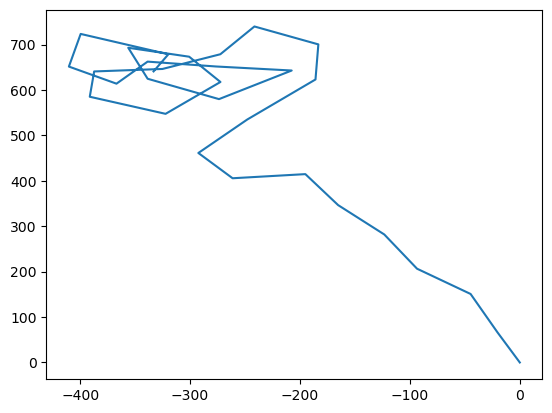

In [8]:
plt.plot(df_calibrated.x.values, df_calibrated.y.values)

### Interpolate

In [9]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), interp_dt)

spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=smoothing_s, k=smoothing_k)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=smoothing_s, k=smoothing_k)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

/var/folders/63/jqdzyjdd4bnghtd7s779bx500000gp/T/ipykernel_11696/414926908.py:3: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=smoothing_s, k=smoothing_k)  # s=smoothing amount
/var/folders/63/jqdzyjdd4bnghtd7s779bx500000gp/T/ipykernel_11696/414926908.py:6: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=smoothing_s, k=smoothing_k) 

### Parameters

In [10]:
df_calibrated_interp.shape

(300, 3)

In [11]:
tix_start = 100
tix_end = 299

100.0


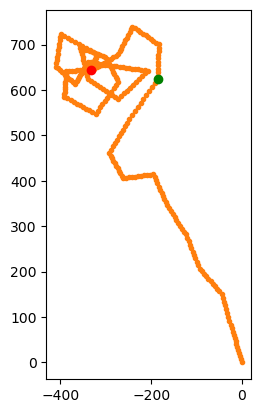

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [13]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [14]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

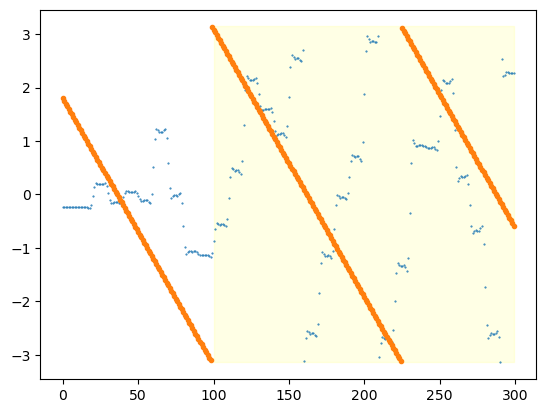

In [15]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.05
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [16]:
min_ix_range = 100
max_ix_range = 120

In [17]:
trajec = df_calibrated_interp

In [18]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [19]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)


trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

In [20]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,)

Restricted license - for non-production use only - expires 2027-11-29


SolverError: Solver 'GUROBI' failed. Try another solver, or solve with verbose=True for more information.

In [21]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length


unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [22]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [23]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
0,155,258,0.122571,-3.851709,-2.674958,1.004785,0.806984,0.964751,0.079473,0.079473,...,0,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
1,137,237,0.124287,-4.157197,-2.645468,0.998268,0.812619,0.956201,0.077718,0.077718,...,1,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
9,130,240,0.129915,1.229801,-2.350143,0.991217,0.699497,0.843592,0.145850,0.145850,...,9,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
2,126,226,0.122266,-3.777758,-2.428577,0.966921,0.693192,0.849801,0.135433,0.135433,...,2,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
6,193,296,0.141366,-1.597619,2.492584,0.902877,0.343267,0.698454,-0.269459,-0.269459,...,6,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
8,114,221,0.125143,1.949384,-2.633314,0.889836,0.475367,0.791668,0.176212,0.176212,...,8,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
5,176,292,0.127993,1.273456,2.213090,0.831394,0.572378,0.665323,-0.124240,-0.124240,...,5,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
3,192,292,0.119477,3.134851,1.558559,0.793425,0.550194,0.550230,0.002976,0.002976,...,3,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
4,107,219,0.123012,-4.005927,-2.608667,0.816292,0.415435,0.712823,0.175415,0.175415,...,4,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial
7,104,216,0.124014,-4.119954,-2.566861,0.794795,0.349597,0.663234,0.203131,0.203131,...,7,albatross_circling_trajec,1.0,5.235988,unknown,NaN,0.9,flying,air,aerial


In [25]:
ix_all, course, linear_fit_angle, affine_fit_angle, shift_ix_adj = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

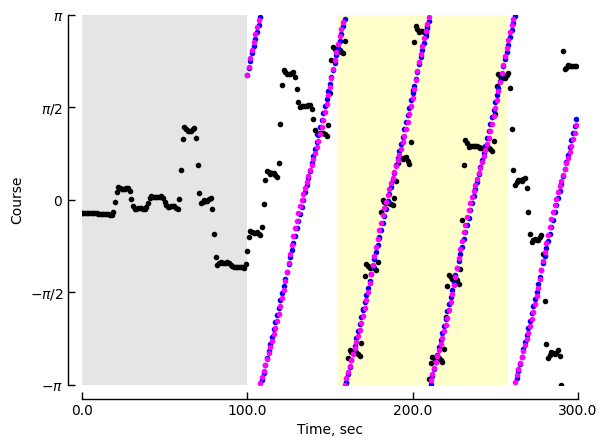

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [27]:
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')